In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score # for the accuracy of the cluster model
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Reading the expanded data
data = pd.read_csv(r"C:\Users\INDIAN\Downloads\Instagram_visits_clustering.csv")
data.head()


,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


In [4]:
data.rename(columns={"Instagram visit score":"instagram_visits","Spending_rank(0 to 100)":"spending_rank"},inplace=True)

In [5]:
data.head()

,User ID,instagram_visits,spending_rank
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


In [6]:
# Selecting Age and Income columns
X = data[["instagram_visits","spending_rank"]]
X.head()

,instagram_visits,spending_rank
0,63,24.050708
1,61,25.223290
2,104,18.528245
3,82,86.890232
4,14,31.492397


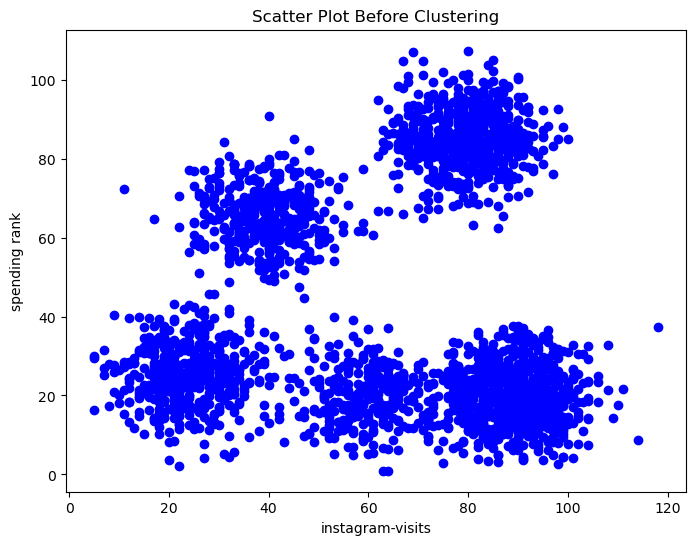

In [7]:
# Scatter plot before clustering
plt.figure(figsize=(8, 6))
plt.scatter(X['instagram_visits'], X['spending_rank'], c='blue')
plt.title('Scatter Plot Before Clustering')
plt.xlabel('instagram-visits')
plt.ylabel('spending rank')
plt.show()

In [8]:
# Applying MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
X_scaled

array([[0.51327434, 0.21718064],
       [0.49557522, 0.2282002 ],
       [0.87610619, 0.16528224],
       ...,
       [0.84070796, 0.78995846],
       [0.72566372, 0.18410168],
       [0.25663717, 0.7090362 ]], shape=(2600, 2))

In [72]:
# Applying DBSCAN clustering
dbscan = DBSCAN(eps=0.05, min_samples=25)
prediction= dbscan.fit_predict(X_scaled)
data['Cluster'] =prediction

In [73]:
prediction

array([ 0,  0,  0, ..., -1,  0,  3], shape=(2600,))

In [74]:
data.head()

,User ID,instagram_visits,spending_rank,Cluster
0,0,63,24.050708,0
1,1,61,25.223290,0
2,2,104,18.528245,0
3,3,82,86.890232,1
4,4,14,31.492397,2


In [75]:
data["Cluster"].value_counts()

Cluster
 0    1031
 1     562
 2     448
 3     344
-1     215
Name: count, dtype: int64

In [71]:
silhouette_score(X_scaled,prediction)

np.float64(0.45102578235115837)

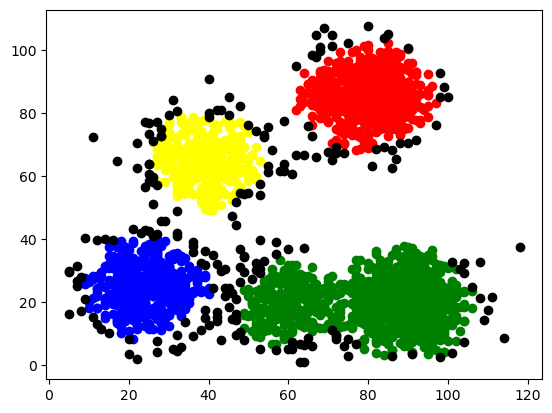

In [76]:
#plotting clusters
df1 = data[data.Cluster==0]
df2 = data[data.Cluster==1]
df3=data[data.Cluster==2]
df4=data[data.Cluster==3]
df5=data[data.Cluster==-1]


plt.scatter(df1['instagram_visits'], df1['spending_rank'],color='green')
plt.scatter(df2['instagram_visits'], df2['spending_rank'],color='red')
plt.scatter(df3['instagram_visits'], df3['spending_rank'],color='blue')
plt.scatter(df4['instagram_visits'], df4['spending_rank'],color='yellow')
plt.scatter(df5['instagram_visits'], df5['spending_rank'],color='black')

plt.show()

In [ ]:
# Example predictions for new data (predictive model)
new_data = np.array([
    [30, 75000],  # John 
    [35, 120000], # Sarah 
    [50, 50000]   # Mike
])

# Scaling new data
new_data_scaled = scaler.transform(new_data)

# Predicting clusters for new data
predictions = dbscan.fit_predict(new_data_scaled)


In [29]:
predictions

array([-1, -1, -1])